In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr

In [2]:
coloc_gdf = gpd.read_parquet("orcestra_coloc_ec_sounders_times.parquet")

In [3]:
overpass_path = Path.home() / "my-public-bucket" / "orcestra" / "overpass_sounders"
overpass_files = sorted(list(overpass_path.glob("*.nc")))

In [4]:
coloc_gdf = coloc_gdf.loc[[
    int(f.stem.split("_")[1])
    for f in overpass_files
]]

In [5]:
coloc_gdf["overpass_file"] = [str(f) for f in overpass_files]

In [6]:
coloc_gdf.columns

Index(['index_coloc', 'frame', 'idx', 'hdim_1', 'hdim_2', 'num',
       'threshold_value', 'max_precip', 'feature', 'time', 'timestr', 'lon',
       'lat', 'geometry', 'cell', 'time_cell', 'index_ec', 'granule', 'date',
       'start_time_ec', 'end_time_ec', 'enclosure_ACM_CAP_2B',
       'enclosure_AC__TC__2B', 'enclosure_ACM_RT__2B', 'enclosure_ALL_DF__2B',
       'enclosure_ATL_EBD_2A', 'enclosure_CPR_CD__2A', 'enclosure_CPR_FMR_2A',
       'index_n20', 'results_n20', 'start_time_n20', 'end_time_n20',
       'index_snpp', 'results_snpp', 'start_time_snpp', 'end_time_snpp',
       'time_diff_n20', 'time_diff_snpp', 'overpass_file', 'mean_time_ec',
       'mean_time_noaa_20', 'mean_time_snpp', 'ec_time_offset',
       'noaa_20_time_offset', 'snpp_time_offset'],
      dtype='str')

In [185]:
coloc_gdf.iloc[15]

index_coloc                                                         89196
frame                                                                 101
idx                                                                   615
hdim_1                                                        3486.666667
hdim_2                                                         328.333333
num                                                                     3
threshold_value                                                         5
max_precip                                                       6.045727
feature                                                             89197
time                                                  2024-08-12 02:30:00
timestr                                               2024-08-12 02:30:00
lon                                                            168.716665
lat                                                             -7.116666
geometry                POLYGON ((168.

In [192]:
dt = xr.open_datatree(coloc_gdf.overpass_file[11])

In [193]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

/tmp/ipykernel_306/2255483815.py:8: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(pcol, ax=ax1, orientation="vertical", label="Surface T [K]")


Text(0.5, 0.98, 'SNPP 2024-08-11 20:51:35')

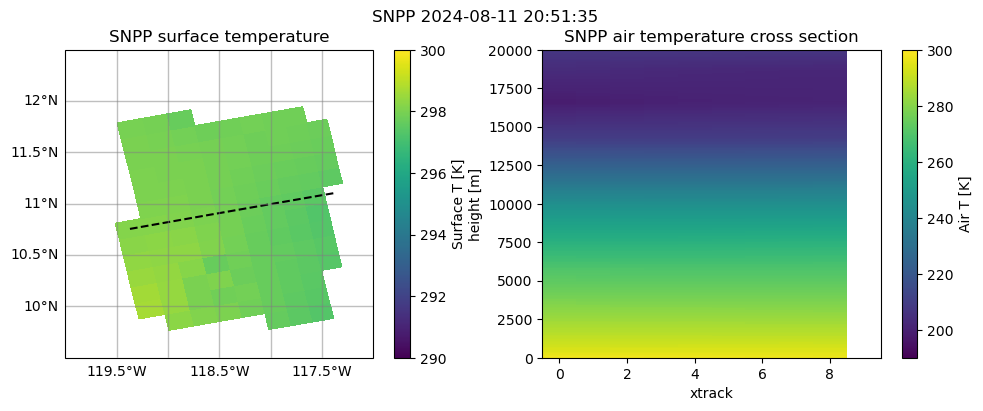

In [228]:
# fig, axes = plt.subplots(1,2,figsize=(12,4), subplot_kw=dict(projection=ccrs.PlateCarree())
fig = plt.figure(figsize=(12,4))
ax1 = plt.subplot(121, projection=ccrs.PlateCarree())
ax1.coastlines()
pcol = ax1.pcolor(
    dt.snpp.lon, dt.snpp.lat, dt.snpp.surf_air_temp, vmin=290, vmax=300
)
plt.colorbar(pcol, ax=ax1, orientation="vertical", label="Surface T [K]")
ax1.plot(dt.snpp.lon[7], dt.snpp.lat[7], "k--")
gl = ax1.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
ax1.set_extent([-120,-117, 9.5, 12.5])

ax2 = plt.subplot(122)
dt.snpp.air_temp[7].T.plot(ax=ax2,vmin=190,vmax=300, cbar_kwargs={"label":"Air T [K]"})
# plt.subplots_adjust(hspace=0.5)

ax1.set_title("SNPP surface temperature")
ax2.set_title("SNPP air temperature cross section")

plt.suptitle(f'SNPP {coloc_gdf.mean_time_snpp[11].strftime("%Y-%m-%d %H:%M:%S")}')

/tmp/ipykernel_306/2506508406.py:8: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(pcol, ax=ax1, orientation="vertical", label="Surface T [K]")


Text(0.5, 0.98, 'NOAA 20 2024-08-11 21:15:38')

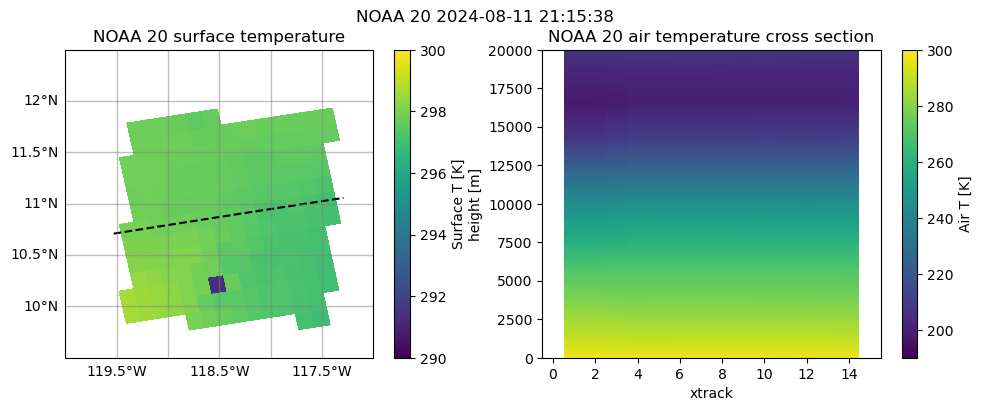

In [226]:
# fig, axes = plt.subplots(1,2,figsize=(12,4), subplot_kw=dict(projection=ccrs.PlateCarree())
fig = plt.figure(figsize=(12,4))
ax1 = plt.subplot(121, projection=ccrs.PlateCarree())
ax1.coastlines()
pcol = ax1.pcolor(
    dt.snpp.lon, dt.snpp.lat, dt.snpp.surf_air_temp, vmin=290, vmax=300
)
plt.colorbar(pcol, ax=ax1, orientation="vertical", label="Surface T [K]")
ax1.plot(dt.snpp.lon[7], dt.snpp.lat[7], "k--")
gl = ax1.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
ax1.set_extent([-120,-117, 9.5, 12.5])

ax2 = plt.subplot(122)
dt.snpp.air_temp[7].T.plot(ax=ax2,vmin=190,vmax=300, cbar_kwargs={"label":"Air T [K]"})
# plt.subplots_adjust(hspace=0.5)

ax1.set_title("NOAA 20 surface temperature")
ax2.set_title("NOAA 20 air temperature cross section")
plt.suptitle(f'NOAA 20 {coloc_gdf.mean_time_snpp[11].strftime("%Y-%m-%d %H:%M:%S")}')

/tmp/ipykernel_306/4287737128.py:8: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar(pcol, ax=ax1, orientation="vertical", label="Surface T [K]")


Text(0.5, 0.98, 'EarthCARE 2024-08-11 22:01:31')

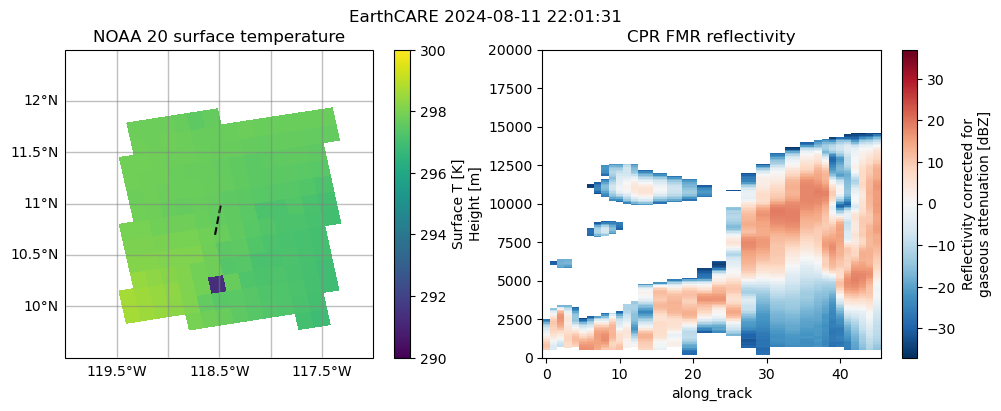

In [227]:
# fig, axes = plt.subplots(1,2,figsize=(12,4), subplot_kw=dict(projection=ccrs.PlateCarree())
fig = plt.figure(figsize=(12,4))
ax1 = plt.subplot(121, projection=ccrs.PlateCarree())
ax1.coastlines()
pcol = ax1.pcolor(
    dt.snpp.lon, dt.snpp.lat, dt.snpp.surf_air_temp, vmin=290, vmax=300
)
plt.colorbar(pcol, ax=ax1, orientation="vertical", label="Surface T [K]")
ax1.plot(dt.CPR_FMR_2A.longitude, dt.CPR_FMR_2A.latitude, "k--")
gl = ax1.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5)
gl.top_labels = False
gl.right_labels = False
ax1.set_extent([-120,-117, 9.5, 12.5])

ax2 = plt.subplot(122)
dt.CPR_FMR_2A.reflectivity_corrected.T.plot(ax=ax2)
# plt.subplots_adjust(hspace=0.5)

ax1.set_title("NOAA 20 surface temperature")
ax2.set_title("CPR FMR reflectivity")
plt.suptitle(f'EarthCARE {coloc_gdf.mean_time_ec[11].strftime("%Y-%m-%d %H:%M:%S")}')